In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

def fit_func(freq, tau, phi_0):
    omega = 2*np.pi*freq
    phi = np.arctan(omega*tau)
    return phi + phi_0

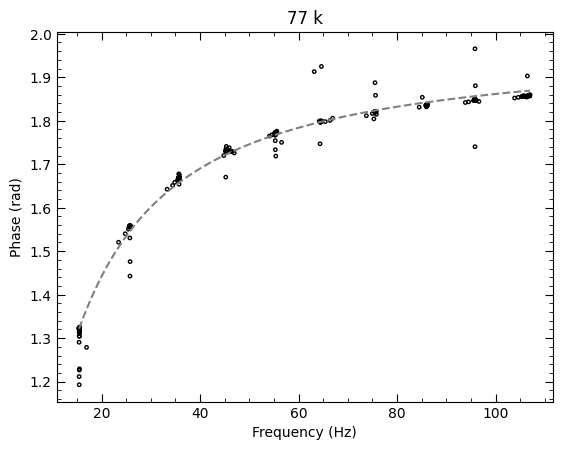

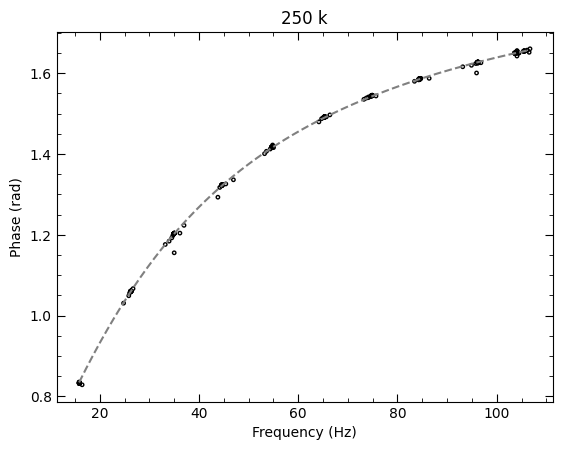

In [16]:
file = "Freq_Data.xlsx"

column_names = [
    ["freq_77", "phase_77"],
    ["freq_250", "phase_250"],
]

df = pd.read_excel(file)

points = [15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
pm = 2

for col in column_names:
    temp = col[0].split("_")[1]

    x_raw = df[col[0]]
    y_raw = df[col[1]]
    y_rad = y_raw * np.pi / 180

    mask = np.zeros_like(x_raw, dtype=bool)

    for p in points:
        mask |= (x_raw >= p - pm) & (x_raw <= p + pm)

    x_sliced = x_raw[mask]
    y_sliced = y_rad[mask]
    y_sliced = np.abs(y_sliced)

    p0 = [0.004,0.4]

    pop, cov = curve_fit(fit_func,
                         x_sliced,
                         y_sliced,
                         p0 = p0,
                         maxfev = 10000)

    x_fit = np.linspace(x_sliced.min(), x_sliced.max(), 10000)

    plt.figure(1)
    plt.scatter(x_sliced, y_sliced,
                marker = 'o', facecolor = 'none',color = "black", s = 6)
    plt.plot(x_fit, fit_func(x_fit, *pop),
             color = "grey", linestyle = "--")

    plt.minorticks_on()
    plt.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    plt.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

    plt.title(f"{temp} k")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (rad)")
    plt.show()